In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import torch
import gc
from pathlib import Path
import scanpy as sc

from models import *
from count_FM_function_v3 import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


# 1. Read Data

In [2]:
data_dir = Path("read_data/datasets/dentate_gyrus")
fp = next(data_dir.glob("*.h5ad"))
print("Loading:", fp)
adata = sc.read_h5ad(fp)
print(adata)

Loading: read_data/datasets/dentate_gyrus/DentateGyrus.h5ad
AnnData object with n_obs × n_vars = 2930 × 13913
    obs: 'age(days)', 'clusters', 'clusters_enlarged', 'index'
    var: 'index'
    obsm: 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


# 2. Data Prep

In [3]:
np.random.seed(123)
torch.manual_seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)

X_layer = adata.layers["matrix"] if "matrix" in adata.layers else adata.X

if sp.issparse(X_layer):
    X1_np = X_layer.toarray().astype(np.float32)
else:
    X1_np = np.asarray(X_layer, dtype=np.float32)

print("X1_np shape:", X1_np.shape, "dtype:", X1_np.dtype)
print("min/max:", float(X1_np.min()), float(X1_np.max()))
print("integer_like:", np.allclose(X1_np, np.round(X1_np)))
print("nonnegative:", bool((X1_np >= 0).all()))

X1_torch = torch.tensor(X1_np, dtype=torch.float32)  # keep CPU
N1, d = X1_torch.shape
print("N1, d =", N1, d)

X1_np shape: (2930, 13913) dtype: float32
min/max: 0.0 1718.0
integer_like: True
nonnegative: True
N1, d = 2930 13913


# 3. Model

In [4]:
separate_heads = False

net_base = ChunkedAdaLNTransformer(
    dim=d,
    out_dim=2*d,
    time_varying=True,
    d_model=256,
    depth=8,
    n_heads=8,
    mlp_ratio=4.0,
    dropout=0.0,
    chunk_size=128,
).to(device)

In [5]:
nets = ChunkedAdaLNTransformer_rate(net_base).to(device)
n_params = sum(p.numel() for p in nets.parameters())

print("model params =", n_params)

model params = 9857792


# 4. Training

In [6]:
age = adata.obs["age(days)"].astype(str).values
idx12 = np.where(age == "12")[0]
idx35 = np.where(age == "35")[0]

rng = np.random.default_rng(123)
rng.shuffle(idx12)
rng.shuffle(idx35)

n12_tr = int(0.8 * len(idx12))
n35_tr = int(0.8 * len(idx35))

idx12_tr, idx12_te = idx12[:n12_tr], idx12[n12_tr:]
idx35_tr, idx35_te = idx35[:n35_tr], idx35[n35_tr:]

print("age12 train/test:", len(idx12_tr), len(idx12_te))
print("age35 train/test:", len(idx35_tr), len(idx35_te))

age12 train/test: 899 225
age35 train/test: 1444 362


In [7]:
X0_tr = torch.from_numpy(X1_np[idx12_tr]).float()
X1_tr = torch.from_numpy(X1_np[idx35_tr]).float()
X0_te = torch.from_numpy(X1_np[idx12_te]).float()
X1_te = torch.from_numpy(X1_np[idx35_te]).float()

In [9]:
lr = 5e-4
optimizer = torch.optim.Adam(nets.parameters(), lr=lr)

In [10]:
batch_size = 32
num_epochs = 1000
eps_t = 1e-4
eps_log = 1e-8
loss_mode = "poisson"
margin = 2

nets.train()
nets, loss = CountFM_train(
    X1_torch=X1_tr,
    nets=nets,
    optimizer=optimizer,
    num_epochs=num_epochs,
    batch_size=batch_size,
    device=device,
    separate_heads=separate_heads,
    X0_torch=X0_tr,
    x0_mode="dataset",
    ot_cost="sym_poisson",
    margin=margin,
    eps_t=eps_t,
    eps_log=eps_log,
    loss_mode=loss_mode,
)
print("final loss", float(loss))

  0%|                                                  | 0/1000 [00:00<?, ?it/s]/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/torch/utils/_device.py:103: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return func(*args, **kwargs)
  0%|                                          | 1/1000 [00:01<18:59,  1.14s/it]

[CountFM][epoch 0] loss=4331.676270


 20%|████████                                | 201/1000 [03:19<13:18,  1.00it/s]

[CountFM][epoch 200] loss=2559.247070


 40%|████████████████                        | 401/1000 [06:40<10:01,  1.00s/it]

...

[CountFM][epoch 600] loss=2778.286621


 80%|████████████████████████████████        | 801/1000 [13:22<03:19,  1.00s/it]

[CountFM][epoch 800] loss=314.802185


100%|███████████████████████████████████████| 1000/1000 [16:41<00:00,  1.00s/it]

final loss -35.15301513671875


# 5. Generation

In [11]:
@torch.no_grad()
def sample_euler_batched_with_snaps(
    nets, n_step, x0_cpu, device,
    batch_eval=32, eps_t=1e-4, eps_log=1e-8, separate_heads=False,
    snap_ids=None, snap_n=0
):
    nets.eval()
    N, d = x0_cpu.shape

    if snap_ids is None or snap_n <= 0:
        snap_set = set()
        snap_ids = []
    else:
        snap_ids = sorted(set(int(s) for s in snap_ids))
        snap_set = set(snap_ids)

    snaps = {}
    if snap_set:
        for s in snap_ids:
            snaps[s] = torch.empty((snap_n, d), dtype=torch.float32, device="cpu")

    outs = []
    Delta = (1.0 - 2.0 * eps_t) / float(n_step)
    Delta_t = torch.tensor(Delta, device=device, dtype=torch.float32)

    for start in range(0, N, batch_eval):
        end = min(start + batch_eval, N)
        xt = x0_cpu[start:end].to(device=device, dtype=torch.float32).clone()
        B = xt.shape[0]
        t = torch.full((B, 1), eps_t, device=device, dtype=torch.float32)

        # step 0 snapshot
        if 0 in snap_set and start < snap_n:
            take = min(end, snap_n) - start
            if take > 0:
                snaps[0][start:start+take] = xt[:take].detach().cpu()

        for k in range(1, n_step + 1):
            xt_t = torch.cat([xt, t], dim=1)

            if not separate_heads:
                out = nets(xt_t)
                lambda_theta, beta_theta = out[:, :d], out[:, d:]
            else:
                lambda_theta = nets[0](xt_t)
                beta_theta   = nets[1](xt_t)

            idx_0 = (xt <= 0).to(torch.float32)
            mu_theta = (xt * beta_theta) * (1.0 - idx_0)

            r_i = lambda_theta + mu_theta
            p_none  = torch.exp(-r_i * Delta_t)
            p_jump  = 1.0 - p_none
            p_birth = p_jump * (lambda_theta / (r_i + eps_log))
            p_death = p_jump * (mu_theta     / (r_i + eps_log))

            probs3 = torch.stack([p_none, p_birth, p_death], dim=-1)
            choice = torch.multinomial(probs3.reshape(-1, 3), 1).view(B, d)

            adj = (choice == 1).to(torch.float32) - (choice == 2).to(torch.float32)
            xt = torch.clamp(xt + adj, min=0.0)

            t = torch.minimum(t + Delta_t, torch.full_like(t, 1.0 - eps_t))
            if k in snap_set and start < snap_n:
                take = min(end, snap_n) - start
                if take > 0:
                    snaps[k][start:start+take] = xt[:take].detach().cpu()

        outs.append(xt.to(torch.long).cpu())

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    x1_all = torch.cat(outs, dim=0)
    return x1_all, snaps

In [12]:
n_step_eval = 500
batch_eval = 32

t_show = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], dtype=np.float32)
snap_ids = np.clip(np.round(t_show * n_step_eval).astype(int), 0, n_step_eval)

N_vis = 2000

X0_tr_map = X0_tr.clone()
X0_te_map = X0_te.clone()

print("snap_ids", snap_ids, "N_vis", N_vis)

snap_ids [  0 100 200 300 400 500] N_vis 2000


In [13]:
x1_tr_gen, snaps_tr = sample_euler_batched_with_snaps(
    nets=nets,
    n_step=n_step_eval,
    x0_cpu=X0_tr_map,
    device=device,
    batch_eval=batch_eval,
    eps_t=eps_t,
    eps_log=eps_log,
    separate_heads=separate_heads,
    snap_ids=snap_ids,
    snap_n=min(N_vis, X0_tr_map.shape[0]),
)

x1_te_gen, snaps_te = sample_euler_batched_with_snaps(
    nets=nets,
    n_step=n_step_eval,
    x0_cpu=X0_te_map,
    device=device,
    batch_eval=batch_eval,
    eps_t=eps_t,
    eps_log=eps_log,
    separate_heads=separate_heads,
    snap_ids=snap_ids,
    snap_n=min(N_vis, X0_te_map.shape[0]),
)


In [14]:
traj_snap_tr_counts = np.stack([snaps_tr[int(s)].numpy() for s in snap_ids], axis=0)

print("x1_tr_gen shape:", tuple(x1_tr_gen.shape))
print("traj_snap_tr_counts shape:", traj_snap_tr_counts.shape)

traj_snap_te_counts = np.stack([snaps_te[int(s)].numpy() for s in snap_ids], axis=0)

print("x1_te_gen shape:", tuple(x1_te_gen.shape))
print("traj_snap_te_counts shape:", traj_snap_te_counts.shape)

x1_tr_gen shape: (899, 13913)
traj_snap_tr_counts shape: (6, 899, 13913)
x1_te_gen shape: (225, 13913)
traj_snap_te_counts shape: (6, 225, 13913)


# 6. PCA

In [15]:
def log1p_libnorm_np(X, target_sum=1e4):
    X = X.astype(np.float32, copy=False)
    lib = X.sum(axis=1, keepdims=True).astype(np.float32)
    lib = np.maximum(lib, 1.0)
    Xn = X * (target_sum / lib)
    return np.log1p(Xn)

def fit_pca(X_real_counts, g_keep=256):
    X_log = log1p_libnorm_np(X_real_counts)
    g_keep = min(g_keep, X_log.shape[1])
    top_idx = np.argsort(X_log.var(axis=0))[-g_keep:]
    R = X_log[:, top_idx]
    center = R.mean(axis=0)
    _, _, Vt = np.linalg.svd(R - center[None, :], full_matrices=False)
    W = Vt[:2].T
    return top_idx, center.astype(np.float32), W.astype(np.float32)

def proj2(X_counts, top_idx, center, W):
    X_log = log1p_libnorm_np(X_counts)
    X_sel = X_log[:, top_idx]
    return (X_sel - center[None, :]) @ W

def proj2_traj(traj_counts, top_idx, center, W):
    K, B, d_ = traj_counts.shape
    flat = traj_counts.reshape(K * B, d_)
    flat2 = proj2(flat, top_idx, center, W)
    return flat2.reshape(K, B, 2)

## train

In [16]:
src_np = X0_tr.detach().cpu().numpy().astype(np.float32, copy=False)
tgt_np = X1_tr.detach().cpu().numpy().astype(np.float32, copy=False)
gen_np = x1_tr_gen.detach().cpu().numpy().astype(np.float32, copy=False)

fit_np = np.vstack([src_np, tgt_np])
top_idx, center, W = fit_pca(fit_np, g_keep=256)

src_2d = proj2(src_np, top_idx, center, W)
tgt_2d = proj2(tgt_np, top_idx, center, W)
gen_2d = proj2(gen_np, top_idx, center, W)
traj_2d = proj2_traj(traj_snap_tr_counts, top_idx, center, W)

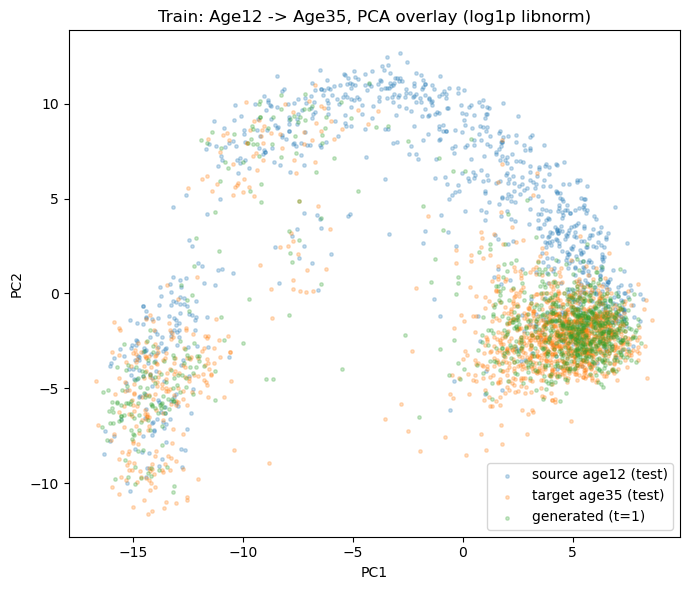

In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(src_2d[:, 0], src_2d[:, 1], s=6, alpha=0.25, label="source age12 (test)")
plt.scatter(tgt_2d[:, 0], tgt_2d[:, 1], s=6, alpha=0.25, label="target age35 (test)")
plt.scatter(gen_2d[:, 0], gen_2d[:, 1], s=6, alpha=0.25, label="generated (t=1)")
plt.title("Train: Age12 -> Age35, PCA overlay (log1p libnorm)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

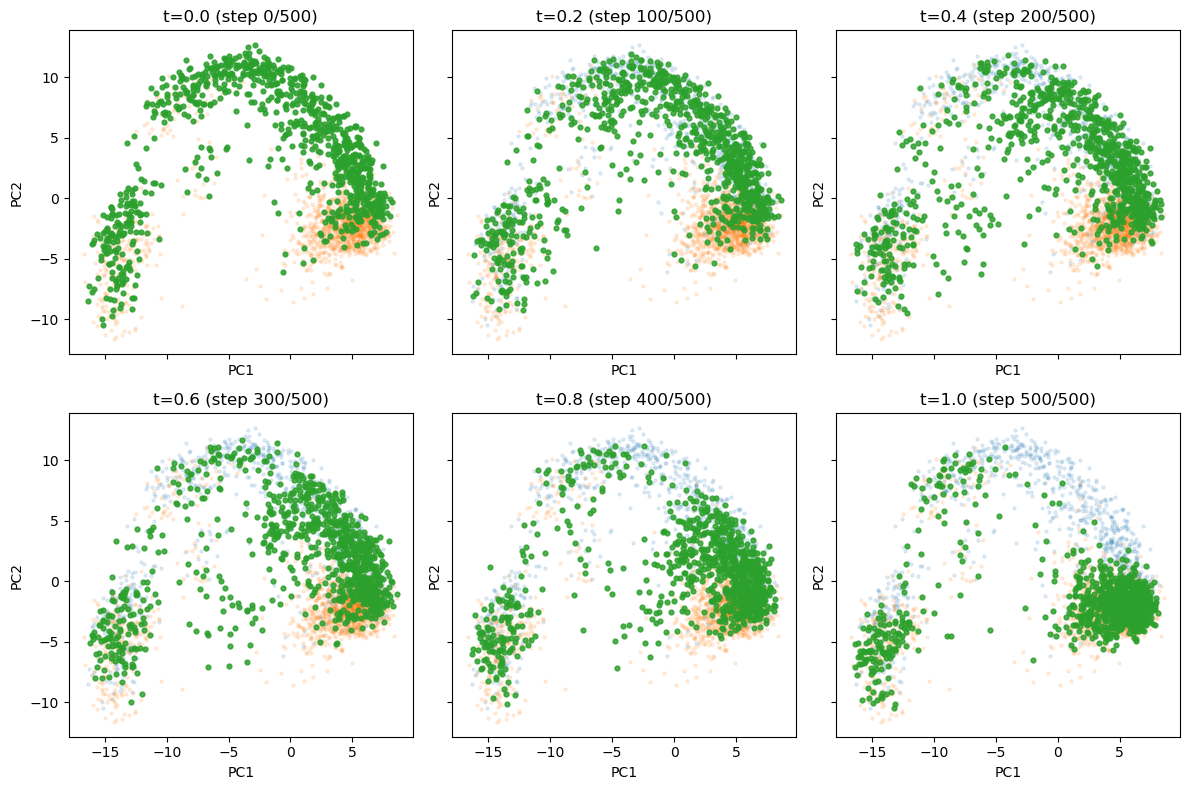

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()
for j, ax in enumerate(axes):
    ax.scatter(src_2d[:, 0], src_2d[:, 1], s=5, alpha=0.12)
    ax.scatter(tgt_2d[:, 0], tgt_2d[:, 1], s=5, alpha=0.12)
    ax.scatter(traj_2d[j, :, 0], traj_2d[j, :, 1], s=12, alpha=0.85)
    ax.set_title(f"t={t_show[j]:.1f} (step {snap_ids[j]}/{n_step_eval})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

## test

In [19]:
src_np = X0_te.detach().cpu().numpy().astype(np.float32, copy=False)
tgt_np = X1_te.detach().cpu().numpy().astype(np.float32, copy=False)
gen_np = x1_te_gen.detach().cpu().numpy().astype(np.float32, copy=False)

fit_np = np.vstack([src_np, tgt_np])
top_idx, center, W = fit_pca(fit_np, g_keep=256)

src_2d = proj2(src_np, top_idx, center, W)
tgt_2d = proj2(tgt_np, top_idx, center, W)
gen_2d = proj2(gen_np, top_idx, center, W)
traj_2d = proj2_traj(traj_snap_te_counts, top_idx, center, W)

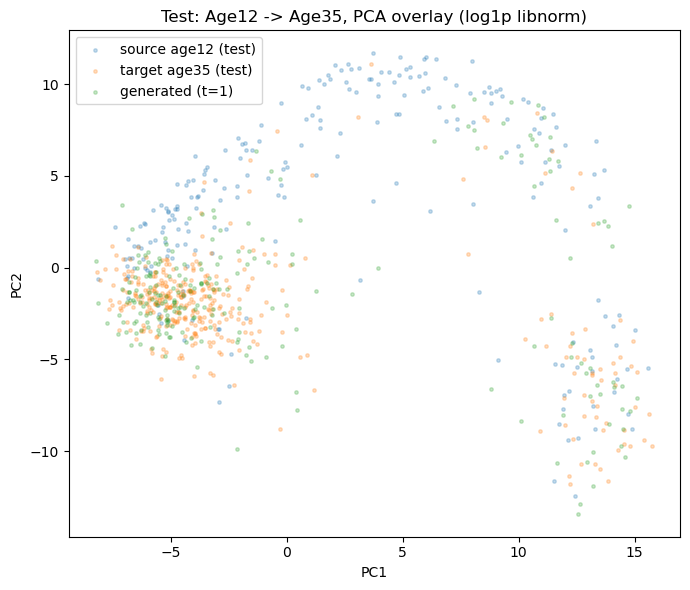

In [20]:
plt.figure(figsize=(7, 6))
plt.scatter(src_2d[:, 0], src_2d[:, 1], s=6, alpha=0.25, label="source age12 (test)")
plt.scatter(tgt_2d[:, 0], tgt_2d[:, 1], s=6, alpha=0.25, label="target age35 (test)")
plt.scatter(gen_2d[:, 0], gen_2d[:, 1], s=6, alpha=0.25, label="generated (t=1)")
plt.title("Test: Age12 -> Age35, PCA overlay (log1p libnorm)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

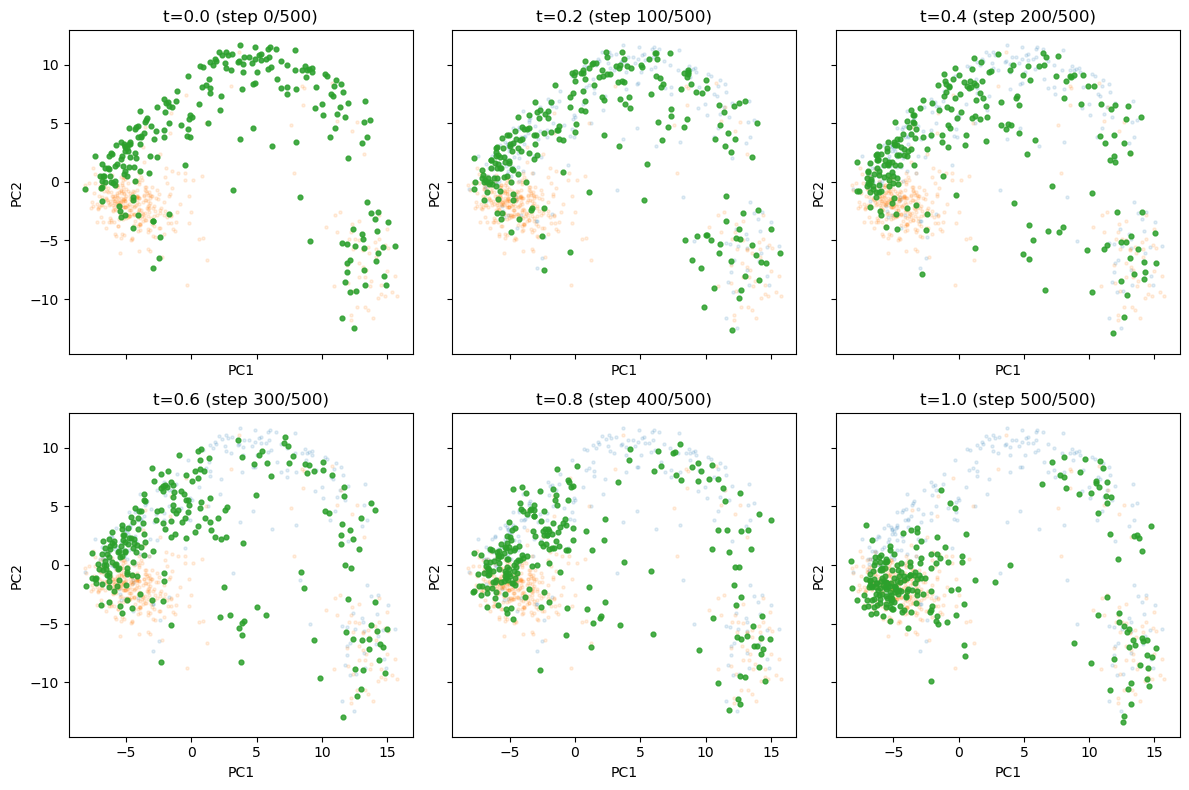

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()
for j, ax in enumerate(axes):
    ax.scatter(src_2d[:, 0], src_2d[:, 1], s=5, alpha=0.12)
    ax.scatter(tgt_2d[:, 0], tgt_2d[:, 1], s=5, alpha=0.12)
    ax.scatter(traj_2d[j, :, 0], traj_2d[j, :, 1], s=12, alpha=0.85)
    ax.set_title(f"t={t_show[j]:.1f} (step {snap_ids[j]}/{n_step_eval})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()